In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add project root
sys.path.append(
    str(Path.cwd().parent)
)

from src.components.prediction_manager import PredictionManager
from src.components.business_advisor import BusinessAdvisor
from src.components.operational_intelligence_engine import (
    OperationalIntelligenceEngine
)
from src.pipeline.recursive_forecast_engine import (
    RecursiveForecastEngine
)

In [2]:
from src.config.configuration import ConfigurationManager

In [3]:
config_manager = ConfigurationManager()

In [4]:
manager = PredictionManager()

advisor = BusinessAdvisor()

oie = OperationalIntelligenceEngine()

engine = RecursiveForecastEngine(config_manager.get_recursive_forecast_config())

r:\Demand_Intelligence_Engine\src\pipeline\prediction_feature_engineering.py:41: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  self.calendar_data = pd.read_csv(
r:\Demand_Intelligence_Engine\src\pipeline\prediction_feature_engineering.py:41: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  self.calendar_data = pd.read_csv(


In [6]:
request = {
    "Store": 1,
    "Date": "2015-08-01",
    "Promo": 0,
    "StateHoliday": "0",
    "SchoolHoliday": 0
}

In [7]:
forecast = engine.forecast(
    request,
    forecast_days=30
)

Current Request:
{'Store': 1, 'Date': '2015-08-01', 'Promo': 0, 'StateHoliday': '0', 'SchoolHoliday': 0}
--------------------------------------------------
Current Request:
{'Store': 1, 'Date': Timestamp('2015-08-02 00:00:00'), 'Promo': 0, 'StateHoliday': 0, 'SchoolHoliday': np.int64(1), 'Open': np.int64(0)}
--------------------------------------------------
Current Request:
{'Store': 1, 'Date': Timestamp('2015-08-03 00:00:00'), 'Promo': 0, 'StateHoliday': 0, 'SchoolHoliday': np.int64(1), 'Open': np.int64(1)}
--------------------------------------------------
Current Request:
{'Store': 1, 'Date': Timestamp('2015-08-04 00:00:00'), 'Promo': 0, 'StateHoliday': 0, 'SchoolHoliday': np.int64(1), 'Open': np.int64(1)}
--------------------------------------------------
Current Request:
{'Store': 1, 'Date': Timestamp('2015-08-05 00:00:00'), 'Promo': 0, 'StateHoliday': 0, 'SchoolHoliday': np.int64(1), 'Open': np.int64(1)}
--------------------------------------------------
Current Request:
{'Store

In [8]:
type(forecast)

dict

In [9]:
forecast_df = forecast["forecast"]

In [10]:
forecast_df.head()

,Date,Promo,Open,StateHoliday,SchoolHoliday,Store,Year,Month,Day,DayOfWeek,...,Sales_Lag_14,Sales_Lag_28,Sales_RollingMean_7,Sales_RollingMean_14,Sales_RollingMean_28,Sales_RollingStd_7,Sales_RollingStd_14,Sales_RollingStd_28,Predicted_Customers,Predicted_Sales
0,2015-08-01,0,1,0,0,1,2015,8,1,6,...,4406.0,4797.0,4363.142857,3845.714286,3779.285714,1995.703922,1785.199296,1691.906570,560.237366,4914.560547
1,2015-08-02,0,0,0,1,1,2015,8,2,7,...,0.0,0.0,4441.794364,3882.040039,3783.484305,2006.562698,1802.566829,1694.669253,214.227890,1669.801392
2,2015-08-03,0,1,0,1,1,2015,8,3,1,...,4395.0,4359.0,4680.337420,4001.311567,3843.120069,1397.250366,1565.611664,1582.247895,526.528748,4437.075195
3,2015-08-04,0,1,0,1,1,2015,8,4,2,...,3558.0,3650.0,4442.491019,4004.316938,3845.908469,1248.726495,1566.465678,1583.259176,498.970123,4045.599121
4,2015-08-05,0,1,0,1,1,2015,8,5,3,...,3464.0,3797.0,4304.576608,4039.145447,3860.037009,1228.622887,1561.190730,1583.211301,472.727112,3896.035645


In [11]:
forecast_df.tail()

,Date,Promo,Open,StateHoliday,SchoolHoliday,Store,Year,Month,Day,DayOfWeek,...,Sales_Lag_14,Sales_Lag_28,Sales_RollingMean_7,Sales_RollingMean_14,Sales_RollingMean_28,Sales_RollingStd_7,Sales_RollingStd_14,Sales_RollingStd_28,Predicted_Customers,Predicted_Sales
25,2015-08-26,0,1,0,1,1,2015,8,26,3,...,3878.225098,4782.000000,3803.424735,3857.376796,3924.433973,503.086664,549.549029,789.973071,413.000977,3556.938232
26,2015-08-27,0,1,0,1,1,2015,8,27,4,...,3877.435547,5020.000000,3791.180036,3834.427734,3880.681767,508.664110,555.289890,774.491128,418.548279,3507.439209
27,2015-08-28,0,1,0,1,1,2015,8,28,5,...,4730.184570,5263.000000,3766.546910,3807.999425,3826.661739,519.022591,561.851517,744.240630,644.978943,5067.666992
28,2015-08-29,0,1,0,1,1,2015,8,29,6,...,4512.145996,4914.560547,3850.826625,3832.105312,3819.685560,677.464289,609.666004,731.077461,703.775208,5509.559570
29,2015-08-30,0,0,0,1,1,2015,8,30,7,...,2781.242188,1669.801392,3993.730225,3903.349139,3840.935525,906.337991,739.664278,771.604488,354.398285,2909.292969


In [12]:
forecast_df.shape

(30, 49)

In [13]:
forecast_df.isna().sum()

Date                          0
Promo                         0
Open                          0
StateHoliday                  0
SchoolHoliday                 0
Store                         0
Year                          0
Month                         0
Day                           0
DayOfWeek                     0
WeekOfYear                    0
Quarter                       0
IsWeekend                     0
StoreType                     0
Assortment                    0
CompetitionDistance           0
CompetitionOpenSinceMonth     0
CompetitionOpenSinceYear      0
Promo2                        0
Promo2SinceWeek               0
Promo2SinceYear               0
PromoInterval                30
CompetitionOpenDate           0
CompetitionAgeMonths          0
CompetitionDateKnown          0
CompetitionActive             0
Promo2StartDate               0
Promo2AgeMonths               0
Promo2Active                  0
Customers_Lag_7               0
Customers_Lag_14              0
Customer

In [14]:
forecast_df[
    [
        "Predicted_Customers",
        "Predicted_Sales"
    ]
].describe()

,Predicted_Customers,Predicted_Sales
count,30.000000,30.000000
mean,472.721985,3845.668213
std,101.351242,789.915771
min,214.227890,1669.801392
25%,420.917862,3578.366455
50%,462.238464,3877.830322
75%,519.639091,4339.847473
max,703.775208,5509.559570


In [15]:
batch_context = (
    oie.generate_batch_operational_intelligence(
        prediction_df=forecast_df
    )
)

In [16]:
batch_context.keys()

dict_keys(['summary', 'promotion', 'top_stores', 'forecast_context', 'explainability'])

In [17]:
summary = advisor.generate_summary(
    batch_context
)

print(
    summary["response"]
)

Based on the provided Business Context, the forecast indicates a total predicted sales of $115,370.05 across 25 open stores, with an average predicted sales of $3,845.67 per store. The forecast also shows a total predicted customer count of 14,181.66, with an average of 472.72 customers per store. The top-performing store is expected to generate $5,509.56 in sales, while the lowest-performing store is expected to generate $1,669.80. There are no active promotions currently in place, which may impact sales performance. Overall, retail managers should be prepared to manage inventory and staffing levels accordingly to meet the forecasted demand, with a focus on optimizing sales and customer service in the top-performing stores.


In [18]:
recommendations = (
    advisor.generate_recommendations(
        batch_context
    )
)

print(
    recommendations["response"]
)

Based on the provided Business Context, here are 5 operational recommendations for the retail manager:

1. **Focus on high-potential stores**: The top stores listed in the Business Context have predicted sales ranging from $4,505 to $5,509. Consider allocating additional resources or attention to these stores to maximize sales potential.
2. **Monitor sales variability**: The sales standard deviation is $789.92, indicating some variability in sales across stores. Regularly review sales performance to identify areas for improvement and adjust strategies accordingly.
3. **Optimize customer experience**: With an average predicted customer count of 472.72, consider strategies to enhance the shopping experience and increase customer satisfaction, such as adjusting staffing levels or improving store layouts.
4. **Review store performance**: The Business Context shows that 5 stores are closed, while 25 are open. Consider analyzing the performance of closed stores to identify potential opportun

In [19]:
answer = advisor.answer_question(
    batch_context,
    """
    What should store managers prepare for
    over the next month?
    """
)

print(
    answer["response"]
)

Based on the provided Business Context, store managers can prepare for the following over the next month:

1. **Sales Performance**: The average predicted sales per store is $3,845.67, with a maximum predicted sales of $5,509.56 and a minimum predicted sales of $1,669.80. This indicates that sales are expected to vary across stores, with some stores potentially experiencing higher sales volumes than others.
2. **Customer Traffic**: The average predicted number of customers per store is 472.72, with a range of customer traffic expected across stores. This suggests that store managers should be prepared to manage varying levels of customer traffic.
3. **No Promotions**: According to the promotion section of the Business Context, there are no active promotions in any stores (promo_active_stores: 0, promo_percentage: 0.0). Store managers should focus on regular sales strategies and customer engagement.
4. **Top-Performing Stores**: The top stores section of the Business Context highlights 

In [20]:
report = advisor.generate_report(
    batch_context
)

print(
    report["response"]
)

**Business Report**

**Executive Summary**

Our retail operations are expected to generate $115,370.05 in sales across 25 open stores, with an average of $3,845.67 per store. We anticipate 14,181.66 customers, averaging 472.72 per store. The top-performing store is expected to achieve $5,509.56 in sales, while the lowest-performing store is expected to reach $1,669.80. This report provides an in-depth analysis of our demand, trends, promotions, and competition, along with operational recommendations to optimize our performance.

**Demand Analysis**

Our total predicted sales of $115,370.05 indicate a moderate demand for our products. The average predicted sales per store of $3,845.67 suggest that our stores are expected to perform relatively consistently. However, there is a notable variation in predicted sales across stores, with a standard deviation of $789.92. This implies that some stores may require more attention and resources to meet their sales targets. The predicted customer t

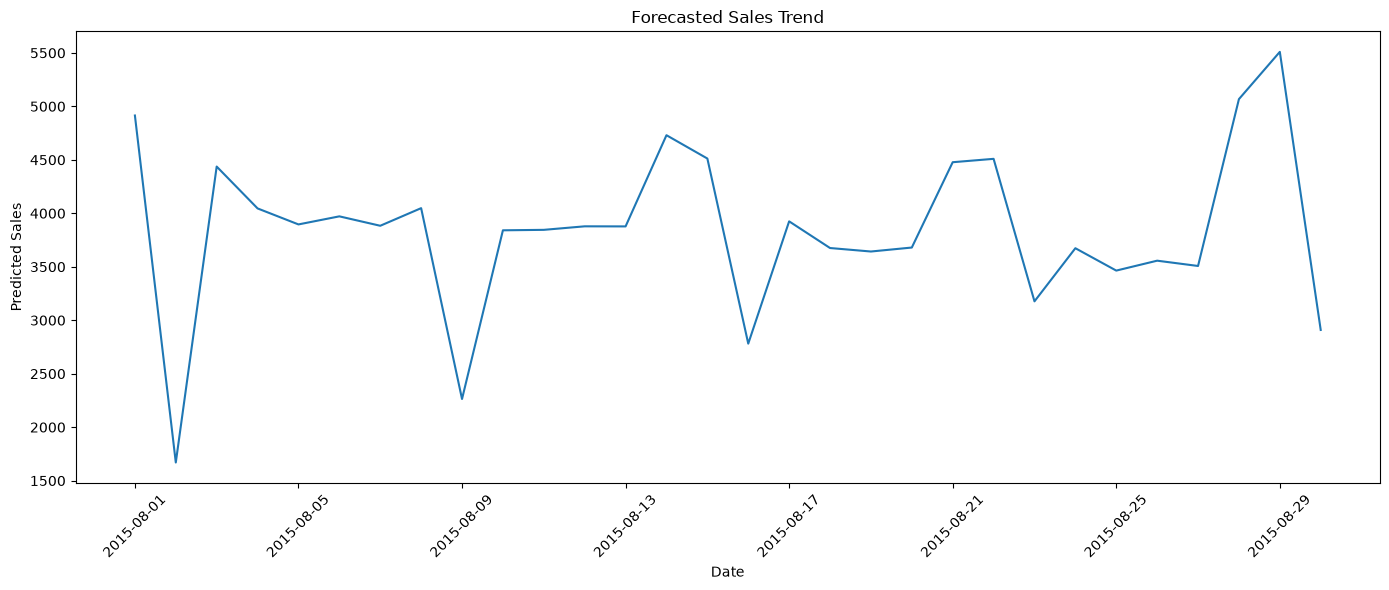

In [21]:
sales_trend = (
    forecast_df
    .groupby("Date")["Predicted_Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))

plt.plot(
    sales_trend["Date"],
    sales_trend["Predicted_Sales"]
)

plt.title(
    "Forecasted Sales Trend"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Predicted Sales"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

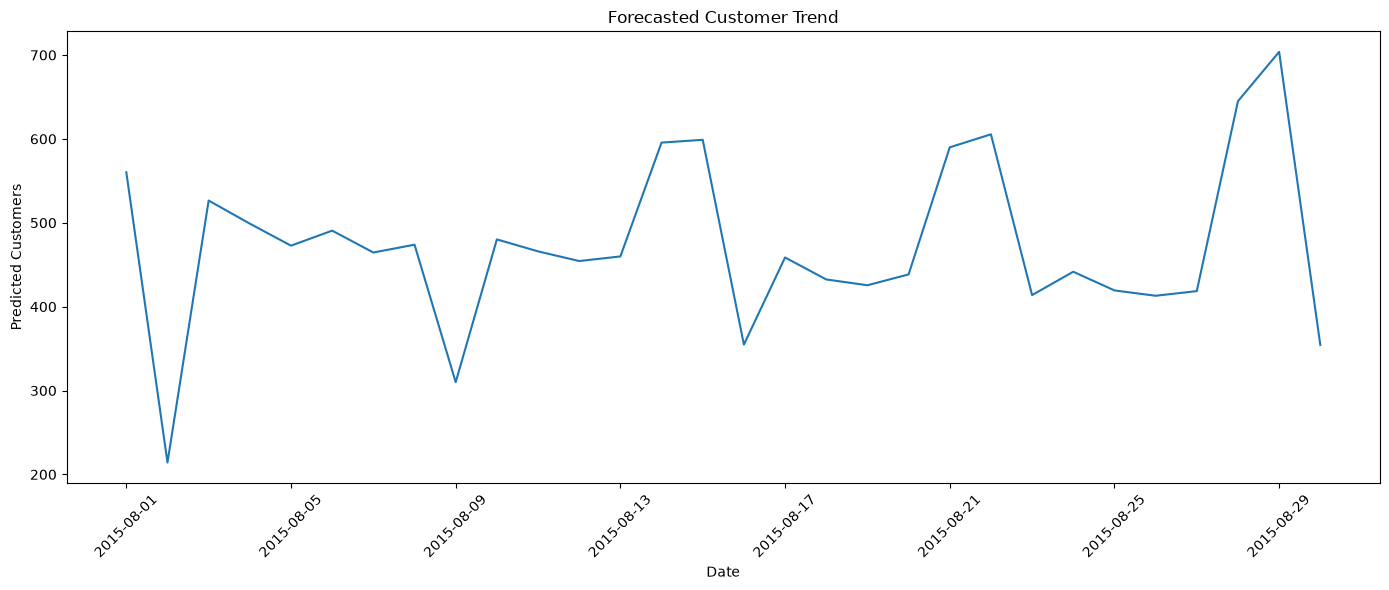

In [22]:
customer_trend = (
    forecast_df
    .groupby("Date")["Predicted_Customers"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))

plt.plot(
    customer_trend["Date"],
    customer_trend["Predicted_Customers"]
)

plt.title(
    "Forecasted Customer Trend"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Predicted Customers"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [23]:
weekly = (
    forecast_df
    .set_index("Date")
    .resample("W")[
        [
            "Predicted_Sales",
            "Predicted_Customers"
        ]
    ]
    .sum()
)

weekly

,Predicted_Sales,Predicted_Customers
Date,,
2015-08-02,6584.361816,774.465271
2015-08-09,26545.263672,3237.348145
2015-08-16,27465.484375,3409.783691
2015-08-23,27086.277344,3364.346191
2015-08-30,27688.660156,3395.716797


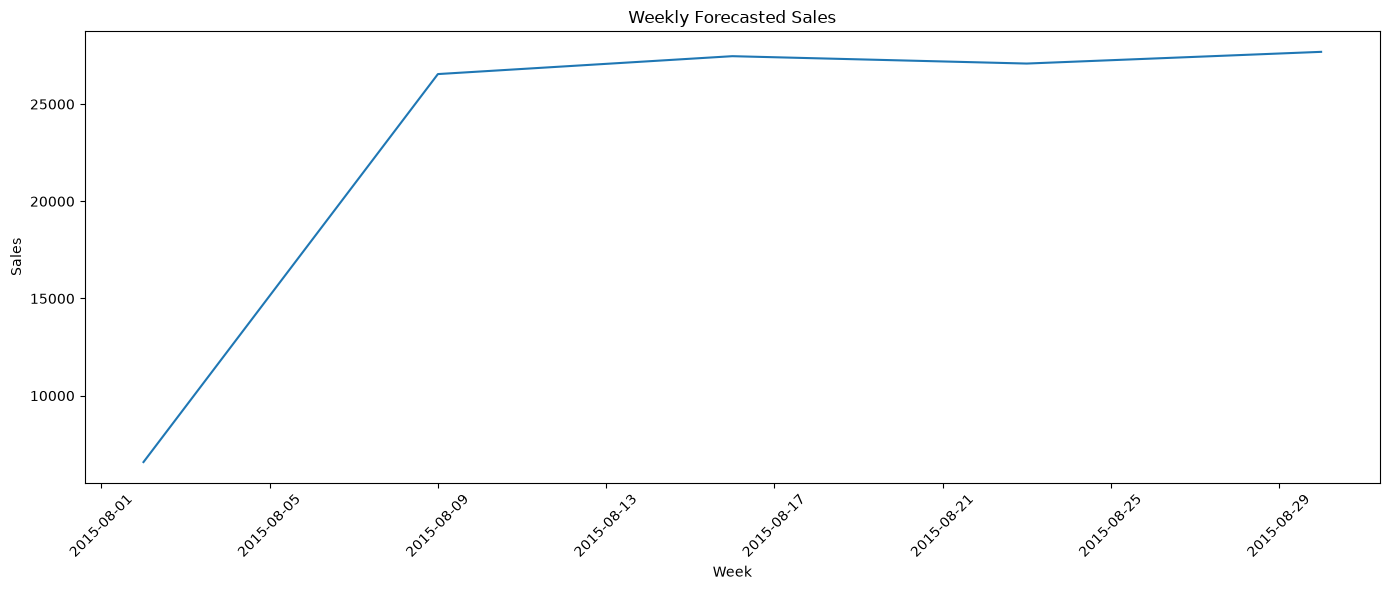

In [24]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly.index,
    weekly["Predicted_Sales"]
)

plt.title(
    "Weekly Forecasted Sales"
)

plt.xlabel(
    "Week"
)

plt.ylabel(
    "Sales"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

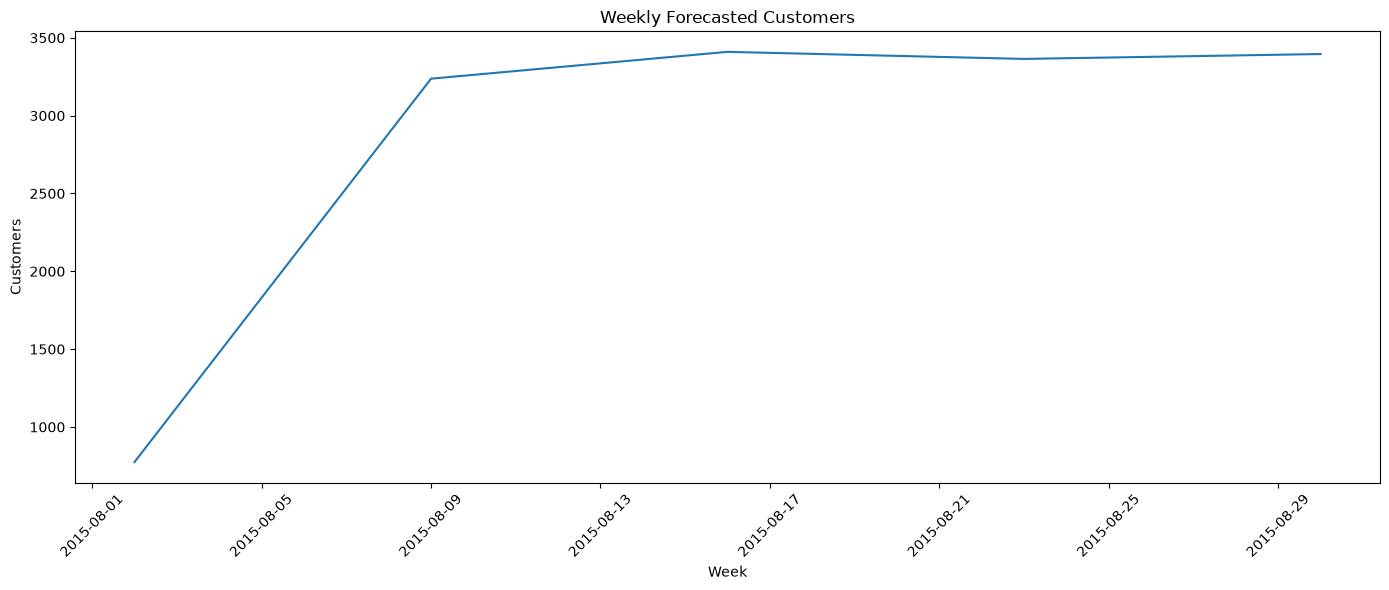

In [25]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly.index,
    weekly["Predicted_Customers"]
)

plt.title(
    "Weekly Forecasted Customers"
)

plt.xlabel(
    "Week"
)

plt.ylabel(
    "Customers"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [26]:
forecast_df.sort_values(
    "Predicted_Sales",
    ascending=False
).head(10)

,Date,Promo,Open,StateHoliday,SchoolHoliday,Store,Year,Month,Day,DayOfWeek,...,Sales_Lag_14,Sales_Lag_28,Sales_RollingMean_7,Sales_RollingMean_14,Sales_RollingMean_28,Sales_RollingStd_7,Sales_RollingStd_14,Sales_RollingStd_28,Predicted_Customers,Predicted_Sales
28,2015-08-29,0,1,0,1,1,2015,8,29,6,...,4512.145996,4914.560547,3850.826625,3832.105312,3819.685560,677.464289,609.666004,731.077461,703.775208,5509.559570
27,2015-08-28,0,1,0,1,1,2015,8,28,5,...,4730.184570,5263.000000,3766.546910,3807.999425,3826.661739,519.022591,561.851517,744.240630,644.978943,5067.666992
0,2015-08-01,0,1,0,0,1,2015,8,1,6,...,4406.000000,4797.000000,4363.142857,3845.714286,3779.285714,1995.703922,1785.199296,1691.906570,560.237366,4914.560547
13,2015-08-14,0,1,0,1,1,2015,8,14,5,...,5263.000000,4852.000000,3662.430315,3845.324053,3830.840598,620.846936,913.218592,1377.994804,595.590088,4730.184570
14,2015-08-15,0,1,0,1,1,2015,8,15,6,...,4914.560547,4406.000000,3783.396066,3807.265808,3826.490047,741.792572,859.090825,1374.840118,598.931824,4512.145996
21,2015-08-22,0,1,0,1,1,2015,8,22,6,...,4048.164307,4364.000000,3813.383998,3798.390032,3947.764618,587.842137,643.191266,1173.399243,605.473145,4509.234375
20,2015-08-21,0,1,0,1,1,2015,8,21,5,...,3883.424316,3706.000000,3849.451939,3755.941127,3920.203583,640.759913,613.850703,1169.547493,589.962341,4477.708984
2,2015-08-03,0,1,0,1,1,2015,8,3,1,...,4395.000000,4359.000000,4680.337420,4001.311567,3843.120069,1397.250366,1565.611664,1582.247895,526.528748,4437.075195
7,2015-08-08,0,1,0,1,1,2015,8,8,6,...,4364.000000,3530.000000,3831.135550,4097.139204,3868.926745,1023.471834,1548.512528,1583.258038,473.882629,4048.164307
3,2015-08-04,0,1,0,1,1,2015,8,4,2,...,3558.000000,3650.000000,4442.491019,4004.316938,3845.908469,1248.726495,1566.465678,1583.259176,498.970123,4045.599121


In [27]:
forecast_df.sort_values(
    "Predicted_Sales"
).head(10)

,Date,Promo,Open,StateHoliday,SchoolHoliday,Store,Year,Month,Day,DayOfWeek,...,Sales_Lag_14,Sales_Lag_28,Sales_RollingMean_7,Sales_RollingMean_14,Sales_RollingMean_28,Sales_RollingStd_7,Sales_RollingStd_14,Sales_RollingStd_28,Predicted_Customers,Predicted_Sales
1,2015-08-02,0,0,0,1,1,2015,8,2,7,...,0.000000,0.000000,4441.794364,3882.040039,3783.484305,2006.562698,1802.566829,1694.669253,214.227890,1669.801392
8,2015-08-09,0,0,0,1,1,2015,8,9,7,...,0.000000,0.000000,3707.364659,4074.579511,3887.432613,917.517002,1546.625168,1582.177685,310.001434,2263.512451
15,2015-08-16,0,0,0,1,1,2015,8,16,7,...,1669.801392,0.000000,3849.679164,3778.521912,3830.280975,788.644133,825.258424,1376.642377,354.806458,2781.242188
29,2015-08-30,0,0,0,1,1,2015,8,30,7,...,2781.242188,1669.801392,3993.730225,3903.349139,3840.935525,906.337991,739.664278,771.604488,354.398285,2909.292969
22,2015-08-23,0,0,0,1,1,2015,8,23,7,...,2263.512451,0.000000,3812.968052,3831.323608,3952.951560,587.266049,668.279240,1175.626220,413.824738,3176.743164
24,2015-08-25,0,1,0,1,1,2015,8,25,2,...,3845.281982,5011.000000,3833.574986,3884.591832,3979.674277,485.386264,537.894688,810.417947,419.375427,3464.271484
26,2015-08-27,0,1,0,1,1,2015,8,27,4,...,3877.435547,5020.000000,3791.180036,3834.427734,3880.681767,508.664110,555.289890,774.491128,418.548279,3507.439209
25,2015-08-26,0,1,0,1,1,2015,8,26,3,...,3878.225098,4782.000000,3803.424735,3857.376796,3924.433973,503.086664,549.549029,789.973071,413.000977,3556.938232
18,2015-08-19,0,1,0,1,1,2015,8,19,3,...,3896.035645,3464.000000,3911.328857,3794.867275,3917.006361,628.055871,615.492416,1171.065028,425.545166,3642.651123
23,2015-08-24,0,1,0,1,1,2015,8,24,1,...,3840.968506,6102.000000,3869.468192,3896.554374,4066.406673,480.844130,534.691561,901.292794,441.639740,3673.492920


In [28]:
forecast_df.sort_values(
    "Predicted_Sales"
).head(10)

,Date,Promo,Open,StateHoliday,SchoolHoliday,Store,Year,Month,Day,DayOfWeek,...,Sales_Lag_14,Sales_Lag_28,Sales_RollingMean_7,Sales_RollingMean_14,Sales_RollingMean_28,Sales_RollingStd_7,Sales_RollingStd_14,Sales_RollingStd_28,Predicted_Customers,Predicted_Sales
1,2015-08-02,0,0,0,1,1,2015,8,2,7,...,0.000000,0.000000,4441.794364,3882.040039,3783.484305,2006.562698,1802.566829,1694.669253,214.227890,1669.801392
8,2015-08-09,0,0,0,1,1,2015,8,9,7,...,0.000000,0.000000,3707.364659,4074.579511,3887.432613,917.517002,1546.625168,1582.177685,310.001434,2263.512451
15,2015-08-16,0,0,0,1,1,2015,8,16,7,...,1669.801392,0.000000,3849.679164,3778.521912,3830.280975,788.644133,825.258424,1376.642377,354.806458,2781.242188
29,2015-08-30,0,0,0,1,1,2015,8,30,7,...,2781.242188,1669.801392,3993.730225,3903.349139,3840.935525,906.337991,739.664278,771.604488,354.398285,2909.292969
22,2015-08-23,0,0,0,1,1,2015,8,23,7,...,2263.512451,0.000000,3812.968052,3831.323608,3952.951560,587.266049,668.279240,1175.626220,413.824738,3176.743164
24,2015-08-25,0,1,0,1,1,2015,8,25,2,...,3845.281982,5011.000000,3833.574986,3884.591832,3979.674277,485.386264,537.894688,810.417947,419.375427,3464.271484
26,2015-08-27,0,1,0,1,1,2015,8,27,4,...,3877.435547,5020.000000,3791.180036,3834.427734,3880.681767,508.664110,555.289890,774.491128,418.548279,3507.439209
25,2015-08-26,0,1,0,1,1,2015,8,26,3,...,3878.225098,4782.000000,3803.424735,3857.376796,3924.433973,503.086664,549.549029,789.973071,413.000977,3556.938232
18,2015-08-19,0,1,0,1,1,2015,8,19,3,...,3896.035645,3464.000000,3911.328857,3794.867275,3917.006361,628.055871,615.492416,1171.065028,425.545166,3642.651123
23,2015-08-24,0,1,0,1,1,2015,8,24,1,...,3840.968506,6102.000000,3869.468192,3896.554374,4066.406673,480.844130,534.691561,901.292794,441.639740,3673.492920


In [6]:
request = {
    "Store": 1,
    "Date": "2015-08-01",
    "Promo": 0,
    "StateHoliday": "0",
    "SchoolHoliday": 0
}

In [7]:
forecast = engine.forecast(
    request,
    target_date="2015-10-05"
)

Current Request:
{'Store': 1, 'Date': '2015-08-01', 'Promo': 0, 'StateHoliday': '0', 'SchoolHoliday': 0}
--------------------------------------------------
Current Request:
{'Store': 1, 'Date': Timestamp('2015-08-02 00:00:00'), 'Promo': 0, 'StateHoliday': 0, 'SchoolHoliday': np.int64(1), 'Open': np.int64(0)}
--------------------------------------------------
Current Request:
{'Store': 1, 'Date': Timestamp('2015-08-03 00:00:00'), 'Promo': 0, 'StateHoliday': 0, 'SchoolHoliday': np.int64(1), 'Open': np.int64(1)}
--------------------------------------------------
Current Request:
{'Store': 1, 'Date': Timestamp('2015-08-04 00:00:00'), 'Promo': 0, 'StateHoliday': 0, 'SchoolHoliday': np.int64(1), 'Open': np.int64(1)}
--------------------------------------------------
Current Request:
{'Store': 1, 'Date': Timestamp('2015-08-05 00:00:00'), 'Promo': 0, 'StateHoliday': 0, 'SchoolHoliday': np.int64(1), 'Open': np.int64(1)}
--------------------------------------------------
Current Request:
{'Store

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(
    str(Path.cwd().parent)
)

from src.config.configuration import ConfigurationManager

from src.pipeline.recursive_forecast_engine import (
    RecursiveForecastEngine
)

from src.components.business_advisor import (
    BusinessAdvisor
)

from src.components.operational_intelligence_engine import (
    OperationalIntelligenceEngine
)

from src.components.forecast_visualiser import (
    ForecastVisualizer
)

In [2]:
config_manager = ConfigurationManager()

engine = RecursiveForecastEngine(
    config_manager.get_recursive_forecast_config()
)

advisor = BusinessAdvisor()

oie = OperationalIntelligenceEngine()

visualizer = ForecastVisualizer(config_manager.get_forecast_visualization_config())

r:\Demand_Intelligence_Engine\src\pipeline\prediction_feature_engineering.py:41: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  self.calendar_data = pd.read_csv(


In [3]:
request = {
    "Store": 1,
    "Promo": 0,
    "Open": 1,
    "StateHoliday": "0",
    "SchoolHoliday": 0,
    "Date": "2015-08-01"
}

In [4]:
forecast = engine.forecast(
    request,
    target_date="2015-10-05"
)

In [5]:
type(forecast)

dict

In [6]:
forecast_df=forecast["forecast"]

In [7]:
forecast_df.head()

,Date,Promo,Open,StateHoliday,SchoolHoliday,Store,Year,Month,Day,DayOfWeek,...,Sales_Lag_14,Sales_Lag_28,Sales_RollingMean_7,Sales_RollingMean_14,Sales_RollingMean_28,Sales_RollingStd_7,Sales_RollingStd_14,Sales_RollingStd_28,Predicted_Customers,Predicted_Sales
0,2015-08-01,0,1,0,0,1,2015,8,1,6,...,4406.0,4797.0,4363.142857,3845.714286,3779.285714,1995.703922,1785.199296,1691.906570,560.237366,4914.560547
1,2015-08-02,0,0,0,1,1,2015,8,2,7,...,0.0,0.0,4441.794364,3882.040039,3783.484305,2006.562698,1802.566829,1694.669253,214.227890,1669.801392
2,2015-08-03,0,1,0,1,1,2015,8,3,1,...,4395.0,4359.0,4680.337420,4001.311567,3843.120069,1397.250366,1565.611664,1582.247895,526.528748,4437.075195
3,2015-08-04,0,1,0,1,1,2015,8,4,2,...,3558.0,3650.0,4442.491019,4004.316938,3845.908469,1248.726495,1566.465678,1583.259176,498.970123,4045.599121
4,2015-08-05,0,1,0,1,1,2015,8,5,3,...,3464.0,3797.0,4304.576608,4039.145447,3860.037009,1228.622887,1561.190730,1583.211301,472.727112,3896.035645


In [8]:
forecast_df.tail()

,Date,Promo,Open,StateHoliday,SchoolHoliday,Store,Year,Month,Day,DayOfWeek,...,Sales_Lag_14,Sales_Lag_28,Sales_RollingMean_7,Sales_RollingMean_14,Sales_RollingMean_28,Sales_RollingStd_7,Sales_RollingStd_14,Sales_RollingStd_28,Predicted_Customers,Predicted_Sales
61,2015-10-01,0,1,0,0,1,2015,10,1,4,...,3573.957031,3937.006348,3974.030901,3929.087838,3997.130284,471.528361,524.672252,544.081056,487.603394,4210.053711
62,2015-10-02,0,0,a,0,1,2015,10,2,5,...,4328.148438,4560.333984,4067.731829,3974.523315,4006.881975,438.174125,519.065374,545.408855,753.554443,6219.191406
63,2015-10-03,0,1,0,0,1,2015,10,3,6,...,5092.812012,5102.837891,4312.703230,4109.597813,4066.126883,928.260832,792.300819,680.997013,684.382690,5453.705566
64,2015-10-04,0,0,0,0,1,2015,10,4,7,...,3493.456299,3622.632812,4421.409354,4135.375924,4078.657872,1020.190425,831.645264,703.631988,553.469849,4332.212891
65,2015-10-05,0,1,0,0,1,2015,10,5,1,...,3620.877930,3851.409668,4462.911133,4195.287109,4104.000017,1008.005570,811.820038,699.364641,445.650696,3953.984619


In [9]:
forecast_df.shape

(66, 49)

In [10]:
forecast_df.isna().sum()

Date                          0
Promo                         0
Open                          0
StateHoliday                  0
SchoolHoliday                 0
Store                         0
Year                          0
Month                         0
Day                           0
DayOfWeek                     0
WeekOfYear                    0
Quarter                       0
IsWeekend                     0
StoreType                     0
Assortment                    0
CompetitionDistance           0
CompetitionOpenSinceMonth     0
CompetitionOpenSinceYear      0
Promo2                        0
Promo2SinceWeek               0
Promo2SinceYear               0
PromoInterval                66
CompetitionOpenDate           0
CompetitionAgeMonths          0
CompetitionDateKnown          0
CompetitionActive             0
Promo2StartDate               0
Promo2AgeMonths               0
Promo2Active                  0
Customers_Lag_7               0
Customers_Lag_14              0
Customer

In [11]:
forecast_df.tail(1)

,Date,Promo,Open,StateHoliday,SchoolHoliday,Store,Year,Month,Day,DayOfWeek,...,Sales_Lag_14,Sales_Lag_28,Sales_RollingMean_7,Sales_RollingMean_14,Sales_RollingMean_28,Sales_RollingStd_7,Sales_RollingStd_14,Sales_RollingStd_28,Predicted_Customers,Predicted_Sales
65,2015-10-05,0,1,0,0,1,2015,10,5,1,...,3620.87793,3851.409668,4462.911133,4195.287109,4104.000017,1008.00557,811.820038,699.364641,445.650696,3953.984619


In [12]:
forecast_df[
    [
        "Predicted_Sales",
        "Predicted_Customers"
    ]
].describe()

,Predicted_Sales,Predicted_Customers
count,66.000000,66.000000
mean,3995.395752,490.656799
std,723.474487,102.892281
min,1669.801392,214.227890
25%,3616.574585,421.529762
50%,3889.729980,463.653458
75%,4410.859619,558.893036
max,6219.191406,753.554443


In [13]:
batch_context = (
    oie.generate_forecast_operational_intelligence(
        forecast_df=forecast_df
    )
)

In [14]:
import pprint
pprint.pprint(batch_context)

{'explainability': None,
 'forecast_context': {'customer_std': np.float32(102.89),
                      'max_sales': np.float32(6219.19),
                      'min_sales': np.float32(1669.8),
                      'sales_std': np.float32(723.47)},
 'summary': {'average_daily_customers': np.float32(490.66),
             'average_daily_sales': np.float32(3995.4),
             'closed_days': 11,
             'forecast_end_date': Timestamp('2015-10-05 00:00:00'),
             'forecast_horizon_days': 66,
             'forecast_start_date': Timestamp('2015-08-01 00:00:00'),
             'open_days': 55,
             'total_predicted_customers': np.float32(32383.35),
             'total_predicted_sales': np.float32(263696.12)},
 'top_forecast_days': [{'Date': Timestamp('2015-10-02 00:00:00'),
                        'Predicted_Customers': 753.554443359375,
                        'Predicted_Sales': 6219.19140625,
                        'Promo': 0},
                       {'Date': Timestam

In [17]:
summary = advisor.generate_summary(
    batch_context
)

print(
    summary["response"]
)

The forecast indicates a total predicted sales of $263,696.12 over the 66-day period, with an average daily sales of $3,995.40. The top forecast days suggest a peak in sales on October 2, 2015, with predicted sales of $6,219.19, indicating a potential high-demand day. The forecast also shows a relatively stable customer traffic pattern, with an average of 490.66 customers per day. There are no promotions indicated in the forecast context, suggesting that the predicted sales are based on regular business operations. Overall, the forecast suggests a steady sales performance with some fluctuation in daily sales, and retail managers should be prepared to manage inventory and staffing accordingly to meet customer demand.


In [18]:
recommendations = (
    advisor.generate_recommendations(
        batch_context
    )
)

print(
    recommendations["response"]
)

Based on the provided Business Context, here are five operational recommendations for the retail manager:

1. **Staffing on Peak Days**: The top forecast days indicate a significant increase in predicted sales and customers. To ensure adequate service, consider adjusting staffing levels on these days, particularly on October 2, which has the highest predicted sales and customers.
2. **Inventory Management**: Although inventory levels are not provided, it's essential to review and manage inventory levels to meet the predicted demand, especially on peak days. Ensure that high-demand products are sufficiently stocked to avoid stockouts and lost sales.
3. **Promotions and Marketing**: The forecast context shows that there are no promotions planned during the forecast period. Consider planning targeted marketing campaigns or promotions to drive sales and attract more customers, especially during periods with lower predicted sales.
4. **Customer Service**: With an average of 490.66 customers

In [19]:
answer = advisor.answer_question(
    batch_context,
    """
    What should management prepare for
    between August and October?
    """
)

print(
    answer["response"]
)

Based on the provided Business Context, between August and October, management should prepare for a period of varying sales and customer traffic. The forecast indicates a total of 55 open days and 11 closed days during this period.

In terms of sales, the average daily sales are predicted to be $3,995.40, with a standard deviation of $723.47. The maximum predicted sales are $6,219.19, and the minimum predicted sales are $1,669.80. This suggests that management should be prepared for fluctuations in daily sales, with some days potentially experiencing significantly higher or lower sales than others.

Regarding customer traffic, the average daily customers are predicted to be 490.66, with a standard deviation of 102.89. The forecast also provides the top forecast days, which include dates such as October 2, August 29, and September 5, with predicted sales and customer traffic ranging from $5,102.84 to $6,219.19 and 684.38 to 753.55 customers, respectively.

To prepare for this period, ma

In [20]:
report = advisor.generate_report(
    batch_context
)

print(
    report["response"]
)

**Business Report**

**Executive Summary**

Our retail business is expected to generate $263,696.12 in sales over the next 66 days, with an average daily sales revenue of $3,995.40. We anticipate serving a total of 32,383 customers, with an average of 490.66 customers per day. The forecast period, which starts on August 1, 2015, and ends on October 5, 2015, includes 55 open days and 11 closed days. This report provides an in-depth analysis of demand, trends, promotions, and competition, along with operational recommendations to optimize business performance.

**Demand Analysis**

The demand forecast indicates a steady stream of customers throughout the period, with an average of 490.66 customers per day. The total predicted sales of $263,696.12 suggest a stable revenue stream. The top forecast days, which include October 2, August 29, and October 3, are expected to drive significant sales, with predicted sales ranging from $5,453.71 to $6,219.19. These days are likely to be critical in

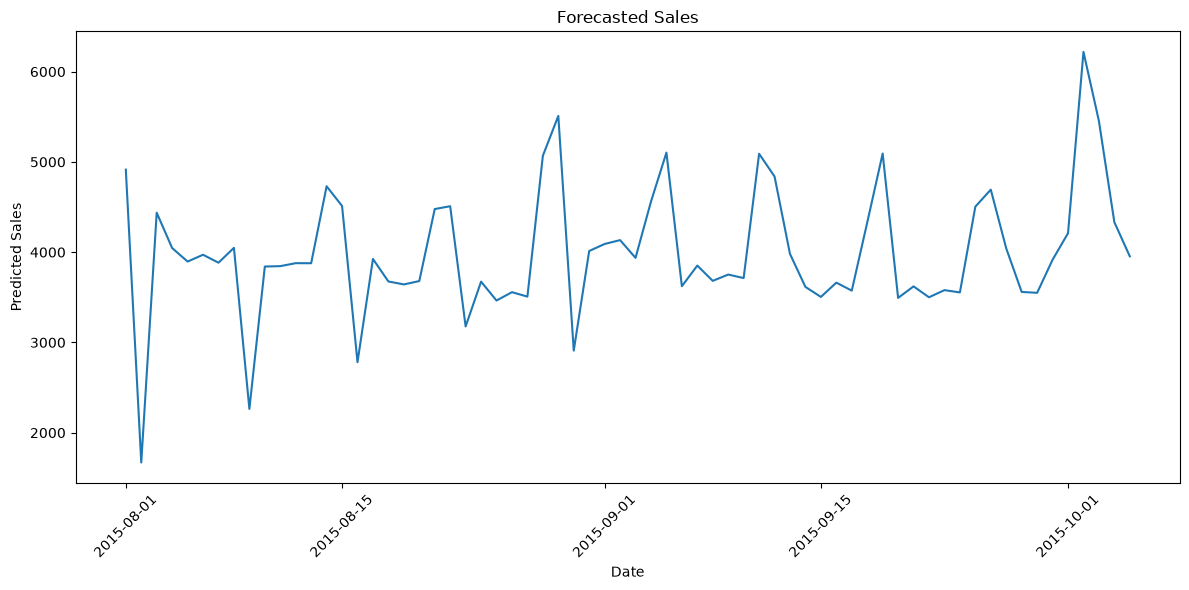

In [21]:
sales_fig = (
    visualizer.plot_sales_forecast(
        forecast_df
    )
)

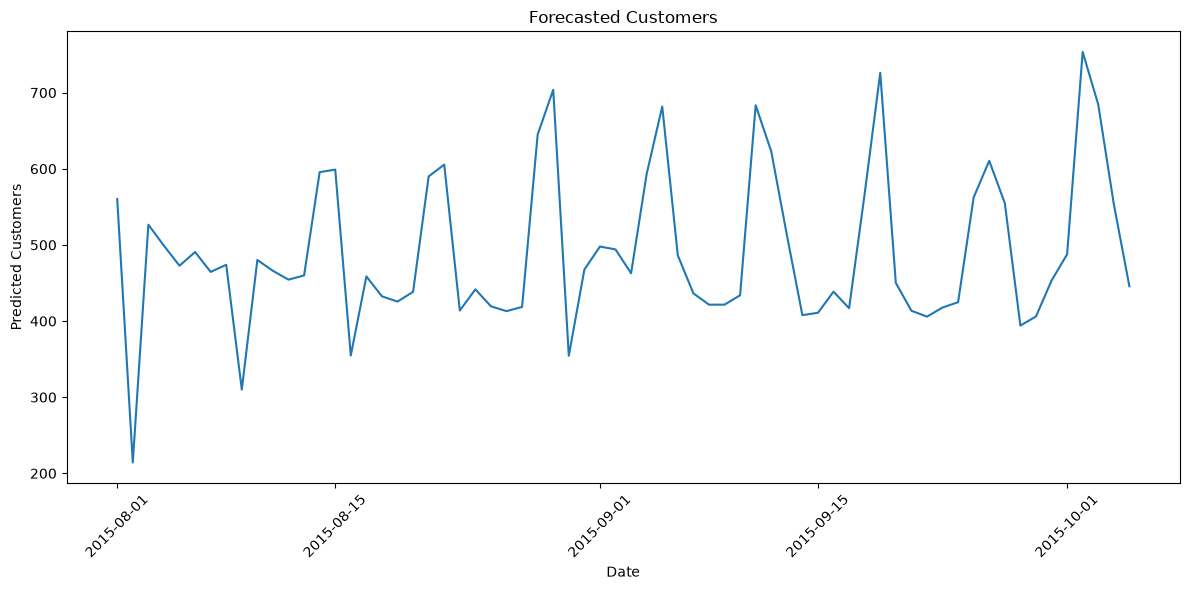

In [22]:
customer_fig = (
    visualizer.plot_customer_forecast(
        forecast_df
    )
)

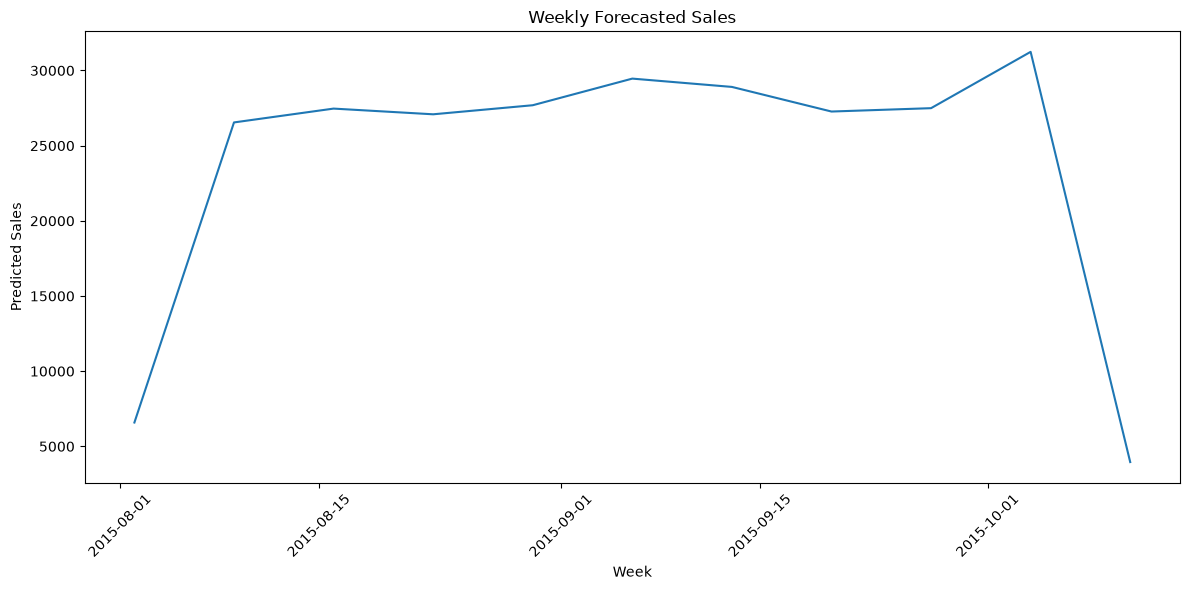

In [23]:
weekly_fig = (
    visualizer.plot_weekly_sales(
        forecast_df
    )
)

In [24]:
visualizer.config

{'forecast_visualization_dir': WindowsPath('R:/Demand_Intelligence_Engine/artifacts/forecast_visualizations'),
 'sales_forecast_plot_path': WindowsPath('R:/Demand_Intelligence_Engine/artifacts/forecast_visualizations/sales_forecast.png'),
 'customer_forecast_plot_path': WindowsPath('R:/Demand_Intelligence_Engine/artifacts/forecast_visualizations/customer_forecast.png'),
 'weekly_sales_plot_path': WindowsPath('R:/Demand_Intelligence_Engine/artifacts/forecast_visualizations/weekly_sales_forecast.png')}

In [25]:
forecast_df["Date"].max()

Timestamp('2015-10-05 00:00:00')

In [26]:
forecast_df["Predicted_Sales"].isna().sum()

np.int64(0)

In [27]:
forecast_df["Predicted_Customers"].isna().sum()

np.int64(0)

In [28]:
import pprint
pprint.pprint(batch_context)

{'explainability': None,
 'forecast_context': {'customer_std': np.float32(102.89),
                      'max_sales': np.float32(6219.19),
                      'min_sales': np.float32(1669.8),
                      'sales_std': np.float32(723.47)},
 'summary': {'average_daily_customers': np.float32(490.66),
             'average_daily_sales': np.float32(3995.4),
             'closed_days': 11,
             'forecast_end_date': Timestamp('2015-10-05 00:00:00'),
             'forecast_horizon_days': 66,
             'forecast_start_date': Timestamp('2015-08-01 00:00:00'),
             'open_days': 55,
             'total_predicted_customers': np.float32(32383.35),
             'total_predicted_sales': np.float32(263696.12)},
 'top_forecast_days': [{'Date': Timestamp('2015-10-02 00:00:00'),
                        'Predicted_Customers': 753.554443359375,
                        'Predicted_Sales': 6219.19140625,
                        'Promo': 0},
                       {'Date': Timestam